## Arkansas Gingles Analysis

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import dill

In [2]:
demographics = ['white', 'black', 'latino', 'other']
candidates = ['harris', 'trump']

### Import Models

In [3]:
path = '../output/Arkansas/models/ei_models.pkl'

In [4]:
with open(path, 'rb') as f:
    models = dill.load(f)

c:\Users\leeh1\Rockies-Gerrymandering\repo\rockies\Lib\site-packages\numba\core\decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


#### Get Sampled Shares Per Model 

In [5]:
def get_sample_shares(models):
    df = pd.DataFrame()

    for candidate in candidates:
        for demographic in demographics:
            ei = models[candidate][demographic]

            samples_matrix = ei.sim_trace["posterior"]["b_1"].stack(all_draws=["chain", "draw"]).values
            
            precinct_means = samples_matrix.mean(axis=1) 
            
            df[f'{demographic}_{candidate}_pct'] = precinct_means
    
    return df

In [6]:
sampled_shares = get_sample_shares(models)
sampled_shares

,white_harris_pct,black_harris_pct,latino_harris_pct,other_harris_pct,white_trump_pct,black_trump_pct,latino_trump_pct,other_trump_pct
0,0.089769,0.621649,0.615536,0.360707,0.897528,0.341397,0.313602,0.500113
1,0.249294,0.814320,0.614282,0.361601,0.708973,0.154308,0.314333,0.496840
2,0.063241,0.522248,0.611636,0.359300,0.924254,0.425539,0.314099,0.500015
3,0.386553,0.858957,0.612258,0.362059,0.571852,0.114763,0.314158,0.499677
4,0.041969,0.619011,0.609688,0.358003,0.952854,0.333626,0.319174,0.501522
...,...,...,...,...,...,...,...,...
2676,0.178865,0.811769,0.622826,0.363323,0.789686,0.157507,0.305731,0.492109
2677,0.095662,0.802553,0.597283,0.352292,0.888175,0.164551,0.327024,0.509665
2678,0.078158,0.798878,0.607704,0.334132,0.910896,0.167225,0.316878,0.530698
2679,0.148626,0.803538,0.613553,0.356545,0.828438,0.165049,0.316286,0.505002


### Path and DataFrame

In [7]:
path = '../output/Arkansas/seawulf.csv'

In [8]:
df = pd.read_csv(path)
df

,Unique_ID,COUNTYFP,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population
0,05001-81 - Stuttgart 2,1,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147
1,05001-36 - Gillett Ward 3,1,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145
2,05001-53 - Dewitt 2,1,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262
3,05001-51 - DeWitt 1,1,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568
4,05001-55 - Dewitt 3,1,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247
...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248
2677,05149-18 - Magazine 1,149,79,354,7,440,763.775521,0.000000,69.265079,45.229741,878.270341
2678,05149-29 - Ions Creek,149,0,19,0,19,141.627233,2.686700,2.303132,13.816984,160.434048
2679,05149-24 - Waveland,149,18,69,1,88,253.978789,7.573110,4.458375,9.804388,275.814662


In [9]:
df.columns = df.columns.str.lower()

### Isolate Columns and Create More Columns

In [10]:
def calculate_shares(df):
    data = pd.DataFrame()

    data['winning_party'] = np.where(
        df['kamala d. harris'] > df['donald j. trump'], 
        'Democratic', 
        'Republican'
    )

    data['rep_vote_share'] = df['donald j. trump'] / df['total_votes']
    data['dem_vote_share'] = df['kamala d. harris'] / df['total_votes']
    data['total_votes'] = df['total_votes']

    for demographic in demographics:
        data[f'{demographic}_pct'] = (
            df[f'{demographic}_population'] / df['total_population']
        )
    
    return data

In [11]:
data = calculate_shares(df)
data

,winning_party,rep_vote_share,dem_vote_share,total_votes,white_pct,black_pct,latino_pct,other_pct
0,Republican,0.671924,0.308097,951,0.554835,0.406971,0.037351,0.000843
1,Republican,0.590909,0.378788,66,0.821938,0.136704,0.012717,0.028642
2,Republican,0.776860,0.202479,242,0.625429,0.361263,0.000325,0.012982
3,Democratic,0.365269,0.604790,167,0.614334,0.372560,0.000000,0.013106
4,Republican,0.858044,0.132492,317,0.783308,0.195137,0.015449,0.006107
...,...,...,...,...,...,...,...,...
2676,Republican,0.592357,0.375796,157,0.686916,0.095730,0.150719,0.066635
2677,Republican,0.804545,0.179545,440,0.869636,0.000000,0.078865,0.051499
2678,Republican,1.000000,0.000000,19,0.882775,0.016746,0.014356,0.086123
2679,Republican,0.784091,0.204545,88,0.920831,0.027457,0.016164,0.035547


### Concatenate

In [12]:
gingles = pd.concat([
    data, sampled_shares
], axis=1)

gingles['id'] = gingles.index + 1

cols = ['id'] + [c for c in gingles.columns if c != 'id']
gingles = gingles[cols]

gingles

,id,winning_party,rep_vote_share,dem_vote_share,total_votes,white_pct,black_pct,latino_pct,other_pct,white_harris_pct,black_harris_pct,latino_harris_pct,other_harris_pct,white_trump_pct,black_trump_pct,latino_trump_pct,other_trump_pct
0,1,Republican,0.671924,0.308097,951,0.554835,0.406971,0.037351,0.000843,0.089769,0.621649,0.615536,0.360707,0.897528,0.341397,0.313602,0.500113
1,2,Republican,0.590909,0.378788,66,0.821938,0.136704,0.012717,0.028642,0.249294,0.814320,0.614282,0.361601,0.708973,0.154308,0.314333,0.496840
2,3,Republican,0.776860,0.202479,242,0.625429,0.361263,0.000325,0.012982,0.063241,0.522248,0.611636,0.359300,0.924254,0.425539,0.314099,0.500015
3,4,Democratic,0.365269,0.604790,167,0.614334,0.372560,0.000000,0.013106,0.386553,0.858957,0.612258,0.362059,0.571852,0.114763,0.314158,0.499677
4,5,Republican,0.858044,0.132492,317,0.783308,0.195137,0.015449,0.006107,0.041969,0.619011,0.609688,0.358003,0.952854,0.333626,0.319174,0.501522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,2677,Republican,0.592357,0.375796,157,0.686916,0.095730,0.150719,0.066635,0.178865,0.811769,0.622826,0.363323,0.789686,0.157507,0.305731,0.492109
2677,2678,Republican,0.804545,0.179545,440,0.869636,0.000000,0.078865,0.051499,0.095662,0.802553,0.597283,0.352292,0.888175,0.164551,0.327024,0.509665
2678,2679,Republican,1.000000,0.000000,19,0.882775,0.016746,0.014356,0.086123,0.078158,0.798878,0.607704,0.334132,0.910896,0.167225,0.316878,0.530698
2679,2680,Republican,0.784091,0.204545,88,0.920831,0.027457,0.016164,0.035547,0.148626,0.803538,0.613553,0.356545,0.828438,0.165049,0.316286,0.505002


### Precincts

In [13]:
def create_precinct_data(gingles):
    precincts = []
    
    for _, row in gingles.iterrows():
        precinct_obj = {
            "id": int(row['id']),
            "groups": {
                "black": {
                    "pct_demo": row['black_pct'],
                    "harris": row['black_harris_pct'],
                    "trump": row['black_trump_pct']
                },
                "latino": {
                    "pct_demo": row['latino_pct'],
                    "harris": row['latino_harris_pct'],
                    "trump": row['latino_trump_pct']
                },
                "other": {
                    "pct_demo": row['other_pct'],
                    "harris": row['other_harris_pct'],
                    "trump": row['other_trump_pct']
                },
                "white": {
                    "pct_demo": row['white_pct'],
                    "harris": row['white_harris_pct'],
                    "trump": row['white_trump_pct']
                }
            }
        }
        precincts.append(precinct_obj)

    return precincts

In [14]:
precincts = create_precinct_data(gingles)
print(precincts[0])

{'id': 1, 'groups': {'black': {'pct_demo': 0.40697080673570896, 'harris': 0.6216489458327397, 'trump': 0.3413971310493551}, 'latino': {'pct_demo': 0.03735136502641747, 'harris': 0.6155355043989098, 'trump': 0.3136016038515658}, 'other': {'pct_demo': 0.0008433041902552423, 'harris': 0.3607073985376738, 'trump': 0.5001128022554294}, 'white': {'pct_demo': 0.5548345240476183, 'harris': 0.08976938297415624, 'trump': 0.8975279112141501}}}


### Non-Linear Regression Line

In [26]:
def sigmoid(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def poly2(x, a, b, c):
    return a * x**2 + b * x + c

def power(x, a, b):
    return a * np.power(np.clip(x, 1e-6, None), b)

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

def linear(x, m, b):
    return m * x + b

MODELS = {
    'sigmoid': (
        sigmoid,
        [1, 5, 0.5],
        ([0, 0, 0], [1, 20, 1])
    ),
    'poly2': (
        poly2,
        [0, 0, 0.5],
        ([-10, -10, 0], [10, 10, 1])
    ),
    'power': (
        power,
        [0.5, 0.1],
        ([0, 0], [2, 5])
    ),
    'exponential': (
        exponential,
        [0.5, 0.1, 0.1],
        ([0, -5, 0], [2, 5, 1])
    ),
    'linear': (
        linear,
        [0, 0.5],                 
        ([-10, 0], [10, 1])       
    ),
}

FORMULAS = {
    'sigmoid':     'L / (1 + exp(-k * (x - x0)))',
    'poly2':       'a*x^2 + b*x + c',
    'power':       'a * x^b',
    'exponential': 'a * exp(b*x) + c',
    'linear':      'm*x + b'
}

In [27]:
def aic(y, yhat, k):
    n = len(y)
    rss = np.sum((y - yhat) ** 2)
    rss = max(rss, 1e-12)  # prevent log(0)
    return n * np.log(rss / n) + 2 * k

def select_best_model(x, y):
    best_name, best_fn, best_params, best_aic_score = None, None, None, np.inf
    for name, (fn, p0, bounds) in MODELS.items():
        try:
            params, cov = curve_fit(fn, x, y, p0=p0, bounds=bounds)
            yhat = fn(x, *params)
            score = aic(y, yhat, k=len(params))
            if score < best_aic_score:
                best_aic_score = score
                best_name   = name
                best_params = params
                best_fn     = lambda xg, fn=fn, params=params: np.clip(fn(xg, *params), 0, 1)
        except Exception:
            continue
    return best_fn, best_name, best_params

In [28]:
FORMULA_TEMPLATES = {
    'sigmoid':     "vote_share = L / (1 + exp(-(b0 + b1 * pct_demo)))",
    'poly2':       "vote_share = a * pct_demo^2 + b * pct_demo + c",
    'power':       "vote_share = a * pct_demo^b",
    'exponential': "vote_share = a * exp(b * pct_demo) + c",
    'linear':      "vote_share = m * pct_demo + b"
}

PARAM_LABELS = {
    'sigmoid':     ['L', 'b1', 'b0'], 
    'poly2':       ['a', 'b', 'c'],
    'power':       ['a', 'b'],
    'exponential': ['a', 'b', 'c'],
    'linear':      ['m', 'b']
}

def select_best_models(gingles, demographics):
    fits = {}
    
    for demographic in demographics:
        x = gingles[f'{demographic}_pct'].values.astype(float)
        candidates_data = []

        for cand in ['harris', 'trump']:
            y = gingles[f'{demographic}_{cand}_pct'].values.astype(float)
            _, name, raw_params = select_best_model(x, y)
            
            if name:
                if name == 'sigmoid':
                    L, k, x0 = raw_params
                    final_params = [float(L), float(k), float(-k * x0)]
                else:
                    final_params = [float(p) for p in raw_params]

                candidates_data.append({
                    'candidate': cand,
                    'model':     name,
                    'formula':   FORMULA_TEMPLATES[name],
                    'params':    dict(zip(PARAM_LABELS[name], final_params))
                })

        fits[demographic] = candidates_data

    return {'fits': fits}

regression = select_best_models(gingles, demographics)
regression

{'fits': {'white': [{'candidate': 'harris',
    'model': 'poly2',
    'formula': 'vote_share = a * pct_demo^2 + b * pct_demo + c',
    'params': {'a': -0.13602769666198955,
     'b': 0.0507729153920533,
     'c': 0.2368399777067107}},
   {'candidate': 'trump',
    'model': 'poly2',
    'formula': 'vote_share = a * pct_demo^2 + b * pct_demo + c',
    'params': {'a': 0.09762807013516771,
     'b': 0.009899269594943132,
     'c': 0.716200761447541}}],
  'black': [{'candidate': 'harris',
    'model': 'poly2',
    'formula': 'vote_share = a * pct_demo^2 + b * pct_demo + c',
    'params': {'a': 0.457660675585478,
     'b': -0.3095029006074482,
     'c': 0.8077188479307428}},
   {'candidate': 'trump',
    'model': 'poly2',
    'formula': 'vote_share = a * pct_demo^2 + b * pct_demo + c',
    'params': {'a': -0.43779402340668244,
     'b': 0.30766872023871156,
     'c': 0.15856481896025276}}],
  'latino': [{'candidate': 'harris',
    'model': 'poly2',
    'formula': 'vote_share = a * pct_demo^2

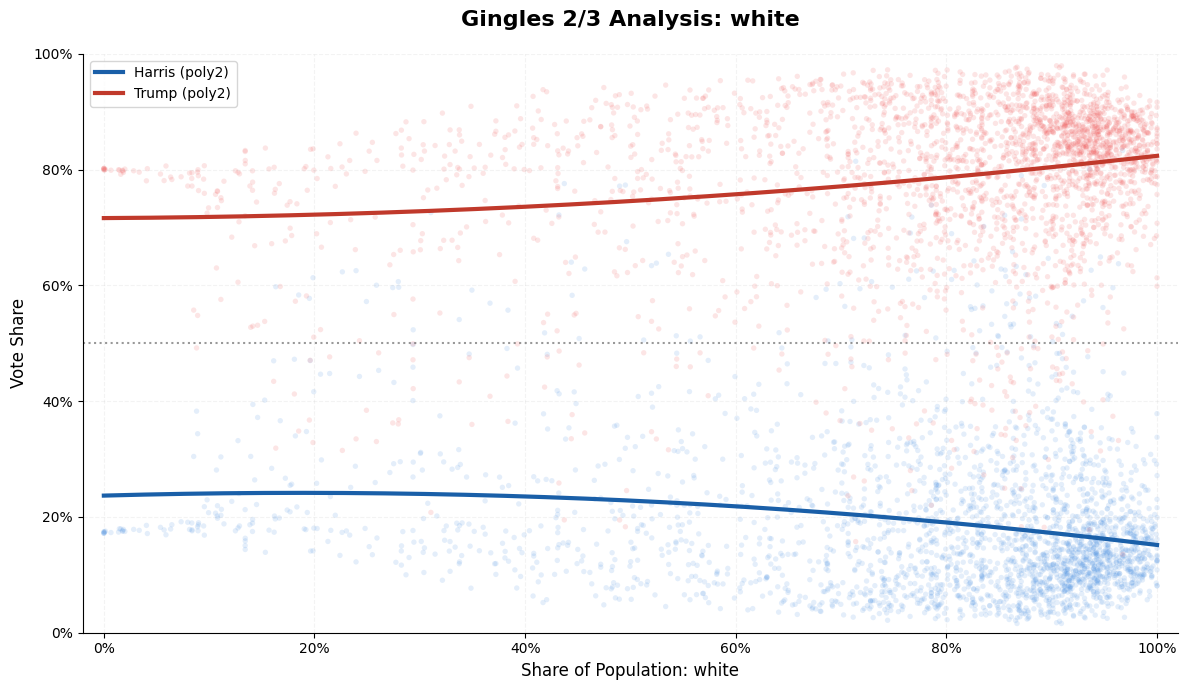

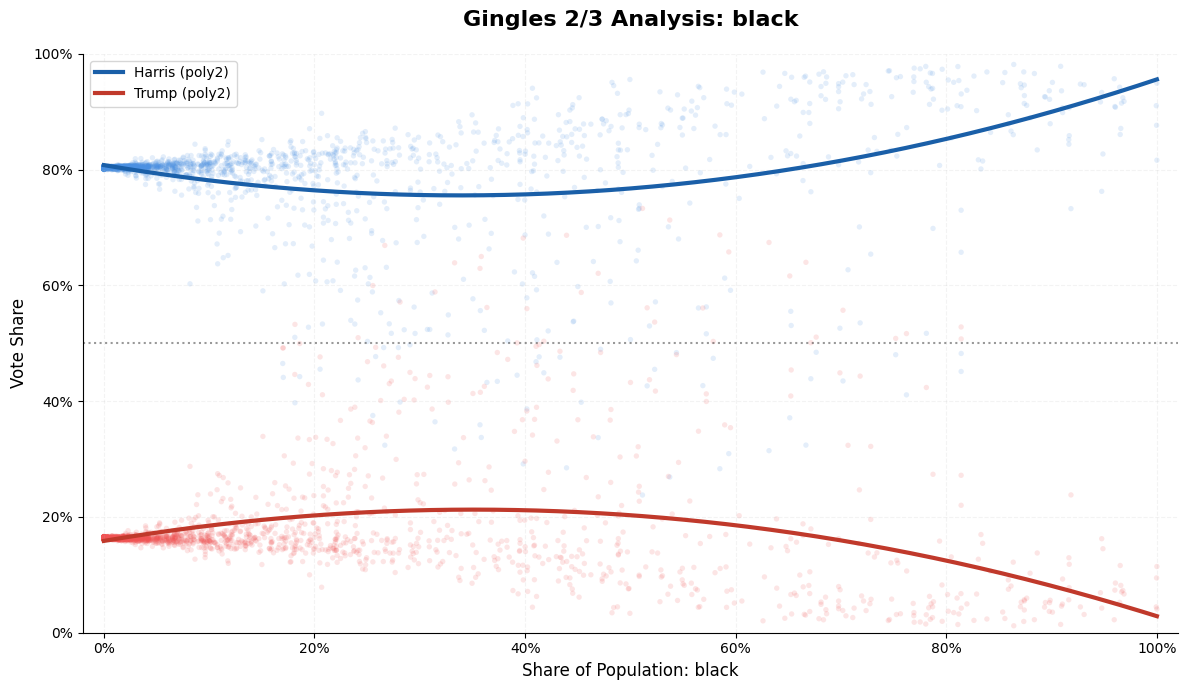

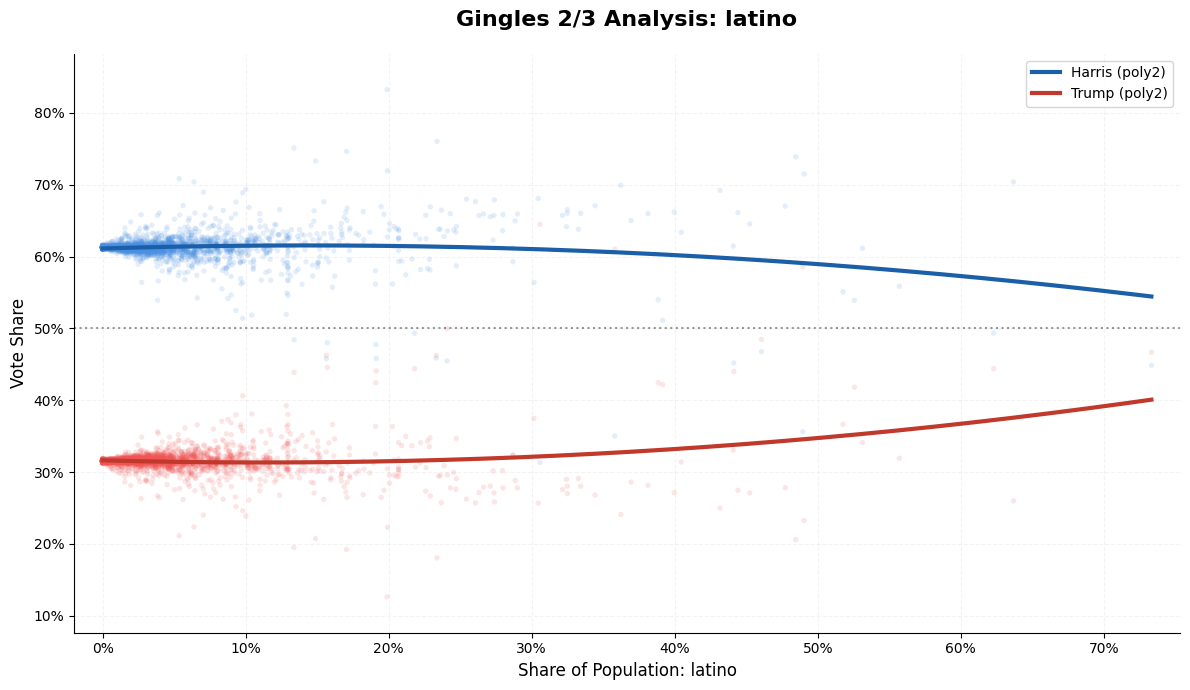

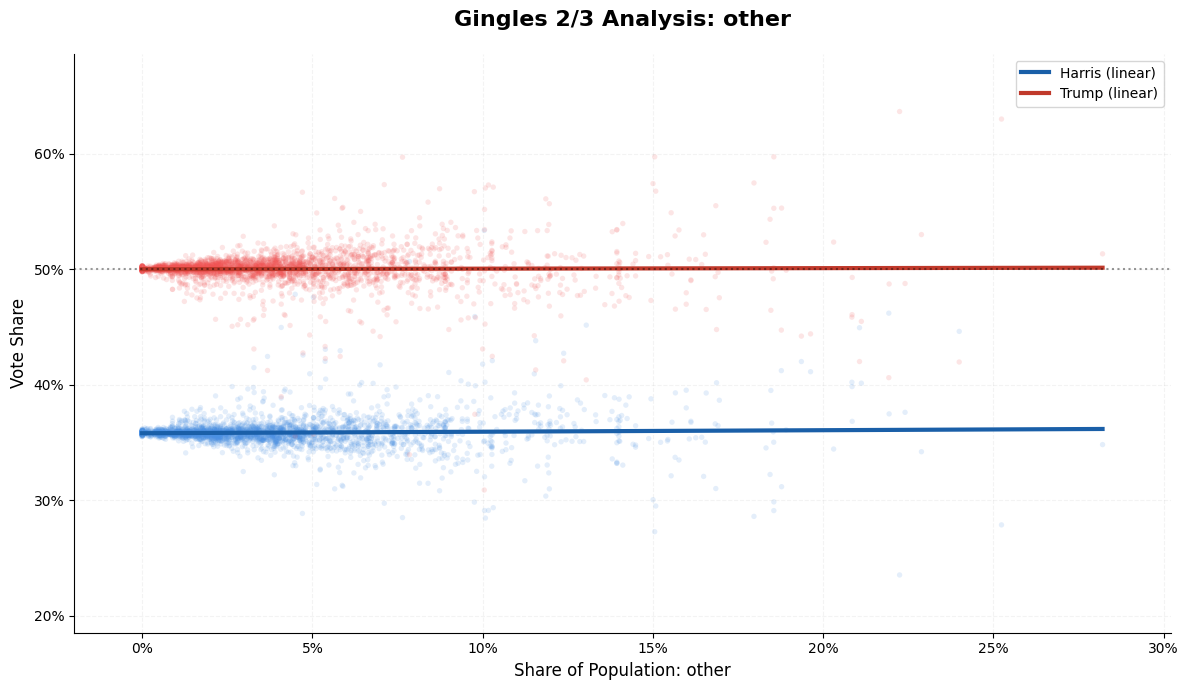

In [29]:
def plot_gingles(result, df, demographic):
    candidateList = result['fits'][demographic]
    harris = next(c for c in candidateList if c['candidate'] == 'harris')
    trump  = next(c for c in candidateList if c['candidate'] == 'trump')

    x  = df[f'{demographic}_pct'].values
    yh = df[f'{demographic}_harris_pct'].values
    yt = df[f'{demographic}_trump_pct'].values
    x_grid = np.linspace(x.min(), x.max(), 500)

    def get_prediction(cand_dict, x_vals):
        name = cand_dict['model']
        p = cand_dict['params']
        
        if name == 'sigmoid':
            y_pred = p['L'] / (1 + np.exp(-(p['b0'] + p['b1'] * x_vals)))
        else:
            fn = MODELS[name][0]
            y_pred = fn(x_vals, *p.values())
            
        return np.clip(y_pred, 0, 1)

    # --- Plotting Code ---
    fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

    # Scatter points
    ax.scatter(x, yh, color='#4A90E2', s=15, alpha=0.15, edgecolors='none')
    ax.scatter(x, yt, color='#F05454', s=15, alpha=0.15, edgecolors='none')

    # Trend lines
    ax.plot(x_grid, get_prediction(harris, x_grid), color='#1a5fa8', lw=3, label=f"Harris ({harris['model']})")
    ax.plot(x_grid, get_prediction(trump, x_grid), color='#c0392b', lw=3, label=f"Trump ({trump['model']})")

    ax.axhline(0.5, color='black', linestyle=':', alpha=0.4)
    
    ax.set_xlim(x.min() - 0.02, x.max() + 0.02)
    y_all = np.concatenate([yh, yt])
    ax.set_ylim(max(0, y_all.min() - 0.05), min(1, y_all.max() + 0.05))

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    ax.set_xlabel(f'Share of Population: {demographic}', fontsize=12)
    ax.set_ylabel('Vote Share', fontsize=12)
    ax.set_title(f'Gingles 2/3 Analysis: {demographic}', fontsize=16, fontweight='bold', pad=20)
    
    ax.legend(frameon=True, loc='best')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.15)

    plt.tight_layout()
    plt.show()

for demographic in demographics:
    plot_gingles(regression, gingles, demographic)

In [30]:
results = {}

for d in demographics:
    x = gingles[f'{d}_pct'].values
    
    results[d] = {}
    for c in candidates:
        y = gingles[f'{d}_{c}_pct'].values
        
        mask = ~np.isnan(x) & ~np.isnan(y)
        corr = np.corrcoef(x[mask], y[mask])[0, 1]
        
        results[d][c] = corr

for d in results:
    print(f"\n{d.upper()}:")
    for c in results[d]:
        print(f"  {c}: {results[d][c]:.4f}")


WHITE:
  harris: -0.1883
  trump: 0.2007

BLACK:
  harris: 0.0393
  trump: -0.0046

LATINO:
  harris: -0.0375
  trump: 0.0884

OTHER:
  harris: 0.0332
  trump: 0.0104


### Save Gingles Data to JSON

In [31]:
def save_to_json(regression, precincts):
    gingles_json = {'state': 'Arkansas', 'regression': regression, 'precincts': precincts}

    with open('../output/Arkansas/ar_gingles_results.json', 'w') as f:
        json.dump(gingles_json, f, indent=4)

save_to_json(regression, precincts)